# S&P 500 Options Case Study: Feasibility Analysis

This notebook tests whether the S&P 500 single-stock options dataset can deliver
on the strategy declared in `config/setup.yaml`. `setup.yaml` is the canonical,
hand-curated source of truth: universe, costs, decision schedule, mapping class,
labels, sweep grid (including the HTM cost-mitigation cascade), and
evaluation protocol. This notebook does not write it. Instead, it produces the
evidence that justifies its values: ATM option spread distributions, VRP
magnitude, the edge-to-cost feasibility ratio, and a walk-forward fold
demonstration. Findings persist to `config/exploration/feasibility_report.json`.

## Learning Objectives

- Verify the data delivers what `setup.yaml` assumes (universe, holdout, cadence)
- Quantify empirical ATM option half-spreads on S&P 500 single-stock straddles
- Measure the volatility risk premium (IV - RV) magnitude vs round-trip cost
- Compute a feasibility ratio that motivates the HTM cost cascade design
- Demonstrate the 2-fold walk-forward structure fits within the 5-year window
- Persist findings as a stable artifact downstream notebooks can cite

## Book Reference

Chapter 6, Sections 6.2-6.6

## Prerequisites

- S&P 500 options data via `load_sp500_options_straddles_raw()` (2017-2021)
- S&P 500 daily bars via `load_sp500_daily_bars()`
- `config/setup.yaml` exists (canonical strategy spec)
- Understanding of options Greeks and the volatility risk premium

In [1]:
"""S&P 500 Options Case Study: Feasibility Analysis."""

import json
import warnings
from datetime import UTC, datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from plotly.subplots import make_subplots

from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from data import load_sp500_daily_bars, load_sp500_options_straddles_raw
from utils.paths import get_case_study_dir
from utils.style import COLORS, ml4t_palette  # registers the ml4t Plotly template on import

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "sp500_options"
START_DATE = "2017-01-01"
# Feasibility sample spans the cross-validation window only; 2021 is the holdout
# (setup.yaml::evaluation.holdout_start) and is deliberately excluded so the
# motivating VRP statistic never touches held-out data.
FEASIBILITY_CV_START = "2017-01-01"
FEASIBILITY_CV_END = "2020-12-31"
FEASIBILITY_SYMBOLS = ["AAPL", "MSFT", "GOOGL", "AMZN"]

## Configuration

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
CASE_DIR.mkdir(parents=True, exist_ok=True)
EXPLORATION_DIR = CASE_DIR / "config" / "exploration"
EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    SETUP = yaml.safe_load(f)

STRATEGY_ID = SETUP["strategy_id"]
END_DATE = "2021-12-31"
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
COST_FRACTIONS = SETUP["backtest"]["sweep"]["htm_cost_cascade"]["cost_fractions"]

---

## Section A: Orientation (Section 6.2)

**Strategy family**: Market mechanics / payoff-driven (options).

**Position on the strategy map**: cross-sectional short-vol harvesting. The
economic claim is that the **volatility risk premium** (VRP = IV - RV)
compensates option sellers for bearing variance risk. We sell ATM single-stock
straddles and hedge delta with the underlying.

**Dominant friction**: costs. Single-stock options have wide quoted spreads
(often 2-5% of option mid per leg). Daily delta hedging adds equity-side costs.
Margin requirements tie up 15-20% of notional. The empirical question this
notebook answers: **does the VRP edge survive the cost stack at any subset
of the universe?**

`setup.yaml` declares the trading setup. This notebook asks whether the data
delivers on those declarations:

- **Universe**: Does S&P 500 options data cover the period and offer breadth?
- **Costs**: How wide are realized ATM spreads vs the expected VRP edge?
- **Evaluation**: Do 2 walk-forward folds fit within the 2017-2020 CV window?
- **Holdout**: Is the 2021 holdout cleanly separated from training data?

---

## Section B: Universe and Cost Feasibility (Sections 6.3-6.4)

### B.1 Load and Verify the Data

We sample the full cross-validation window (2017-2020) for four large, liquid
tech names to characterise ATM behaviour *across regimes* rather than in any
single year. The 2021 holdout is excluded. The full universe (S&P 500
constituents with options coverage) is processed by the downstream pipeline;
here we only need a spread/VRP sample that spans calm and stressed markets.

In [4]:
opts_sample = load_sp500_options_straddles_raw(
    symbols=FEASIBILITY_SYMBOLS,
    start_date=FEASIBILITY_CV_START,
    end_date=FEASIBILITY_CV_END,
)
print(
    f"Options sample: {len(opts_sample):,} rows "
    f"({FEASIBILITY_CV_START[:4]}-{FEASIBILITY_CV_END[:4]} CV window, "
    f"{len(FEASIBILITY_SYMBOLS)} symbols; 2021 holdout excluded)"
)

bars_sample = load_sp500_daily_bars(symbols=FEASIBILITY_SYMBOLS)
print(f"Daily bars: {len(bars_sample):,} rows")

Options sample: 1,848,823 rows (2017-2020 CV window, 4 symbols; 2021 holdout excluded)
Daily bars: 5,036 rows


The raw S&P 500 option chains (~347M rows across all constituents) are reduced
upstream by `data/equities/market/sp500/materialize_options.py` to daily 30D
ATM straddles using delta-based selection (|delta| closest to 0.50, DTE 25-35,
convergence required, min bid $0.01, max spread 30%). The resulting ~372K
straddle rows are what downstream notebooks consume. Here we work with a
four-symbol subset of the broader chain to inspect spread and IV behaviour
before filtering.

### B.2 Universe and Contract Characterisation

The universe is **S&P 500 constituents with listed options coverage** -
approximately 500 single-stock American option chains. Contract selection
rules (target 25-35 DTE, ATM by delta ~0.50) are encoded in the
materialisation script, not in `setup.yaml`, because they are properties of
the dataset rather than tunable strategy knobs.

In [5]:
n_symbols = opts_sample["symbol"].n_unique()
date_range = (opts_sample["timestamp"].min(), opts_sample["timestamp"].max())
print(f"Sample symbols: {n_symbols}")
print(f"Sample date range: {date_range[0]} to {date_range[1]}")
print("Universe (full): S&P 500 constituents with options coverage")

Sample symbols: 4
Sample date range: 2017-01-03 to 2020-12-31
Universe (full): S&P 500 constituents with options coverage


### B.3 ATM Option Quote-Cost Analysis

Single-stock ATM options have spreads that are large relative to their
premium. We first measure the single-leg half-spread relative to mid for
options near the strategy's target window (|delta| 0.35-0.65, DTE 25-35,
bid > $0.05). We then pair complete call and put quotes by contract coordinates
and compute the entry-plus-exit two-leg cost relative to straddle mid.

In [6]:
atm_opts = opts_sample.filter(
    pl.col("delta").abs().is_between(0.35, 0.65)
    & (pl.col("bid") > 0.05)
    & (pl.col("ask") > pl.col("bid"))
    & (pl.col("days_to_maturity").is_between(25, 35))
    & pl.col("call_put").is_in(["C", "P"])
)

atm_opts = atm_opts.with_columns(
    ((pl.col("ask") + pl.col("bid")) / 2).alias("mid"),
    (pl.col("ask") - pl.col("bid")).alias("full_spread"),
).with_columns(
    (pl.col("full_spread") / (2 * pl.col("mid")) * 100).alias("half_spread_pct_of_mid"),
)

pair_keys = ["timestamp", "symbol", "strike", "expiration"]
paired_straddles = (
    atm_opts.group_by(pair_keys)
    .agg(
        pl.len().alias("n_legs"),
        pl.col("call_put").n_unique().alias("n_leg_types"),
        pl.col("full_spread").sum().alias("round_trip_dollars"),
        pl.col("mid").sum().alias("straddle_mid"),
    )
    .filter((pl.col("n_legs") == 2) & (pl.col("n_leg_types") == 2))
    .with_columns(
        (pl.col("round_trip_dollars") / pl.col("straddle_mid") * 100).alias("round_trip_pct_of_mid")
    )
)

The single-leg statistic describes quote width. The paired-straddle statistic
is the economically consistent raw cost: each leg crosses half the spread at
entry and half at exit, for one full dollar spread per leg over the round trip.

In [7]:
half_spread_stats = atm_opts.select(
    pl.col("half_spread_pct_of_mid").mean().alias("mean"),
    pl.col("half_spread_pct_of_mid").median().alias("median"),
    pl.col("half_spread_pct_of_mid").quantile(0.25).alias("q25"),
    pl.col("half_spread_pct_of_mid").quantile(0.75).alias("q75"),
    pl.col("half_spread_pct_of_mid").quantile(0.95).alias("q95"),
).row(0, named=True)
straddle_cost_stats = paired_straddles.select(
    pl.len().alias("n_pairs"),
    pl.col("round_trip_pct_of_mid").mean().alias("mean"),
    pl.col("round_trip_pct_of_mid").median().alias("median"),
    pl.col("round_trip_pct_of_mid").quantile(0.25).alias("q25"),
    pl.col("round_trip_pct_of_mid").quantile(0.75).alias("q75"),
    pl.col("round_trip_pct_of_mid").quantile(0.95).alias("q95"),
).row(0, named=True)

print("ATM single-leg half-spread (% of option mid):")
print(f"  Mean:   {half_spread_stats['mean']:.2f}%")
print(f"  Median: {half_spread_stats['median']:.2f}%")
print(f"  IQR:    [{half_spread_stats['q25']:.2f}%, {half_spread_stats['q75']:.2f}%]")
print(f"  95th:   {half_spread_stats['q95']:.2f}%")
print()
print(f"Complete call-put straddles: {straddle_cost_stats['n_pairs']:,}")
print("Two-leg entry-plus-exit cost (% of straddle mid):")
print(f"  Mean:   {straddle_cost_stats['mean']:.3f}%")
print(f"  Median: {straddle_cost_stats['median']:.3f}%")
print(f"  95th:   {straddle_cost_stats['q95']:.3f}%")

ATM single-leg half-spread (% of option mid):
  Mean:   3.50%
  Median: 2.54%
  IQR:    [1.52%, 4.53%]
  95th:   8.80%

Complete call-put straddles: 80,900
Two-leg entry-plus-exit cost (% of straddle mid):
  Mean:   6.713%
  Median: 5.142%
  95th:   15.854%


These single-leg half-spreads are orders of magnitude wider than typical
equity costs. The complete-pair calculation avoids multiplying an average
leg percentage: it sums call and put dollar spreads and normalizes by their
combined straddle mid before averaging across contracts.

### B.4 Volatility Risk Premium and Feasibility Ratio

We measure VRP as $IV_{30d} - RV_{21d}$ per symbol-day, then compare it to the
round-trip spread cost. Realized volatility uses split-adjusted close returns
within each stable `(symbol, sec_id)` security segment. Resetting the rolling
window when the security identity changes prevents a ticker succession from
becoming a manufactured return. The feasibility ratio is gross VRP edge
divided by raw round-trip spread cost.

The premium is **regime-dependent**, so we report it per calendar year across
the CV window rather than collapsing it into a single number. The pooled
premium is thin and positive, while the 2020 volatility spike drives the
annual mean below zero. The motivating feasibility ratio is computed on the
**pooled** window so a single benign year cannot flatter the assessment.

In [8]:
reconciled_bars = reconcile_underlying_log_returns(bars_sample)
rv_21 = (
    reconciled_bars.with_columns(
        (
            pl.col("clean_log_return").rolling_std(21, min_samples=21).over(["symbol", "sec_id"])
            * np.sqrt(252)
        ).alias("rv_21d"),
    )
    .select(["timestamp", "symbol", "sec_id", "rv_21d"])
    .drop_nulls()
)

Same-day ATM implied volatility joins the trailing realized-volatility estimate
on the canonical symbol-date key. The security identifier remains attached as
an audit field but does not change the option-side key.

In [9]:
iv_daily = (
    atm_opts.group_by(["timestamp", "symbol"])
    .agg(pl.col("implied_vol").mean().alias("iv_30d"))
    .sort(["symbol", "timestamp"])
)

vrp_sample = iv_daily.join(rv_21, on=["timestamp", "symbol"], how="inner")
vrp_sample = vrp_sample.with_columns(
    (pl.col("iv_30d") - pl.col("rv_21d")).alias("vrp"),
    pl.col("timestamp").dt.year().alias("year"),
)

Per-year estimates expose regime dependence; pooled estimates then support the
cost comparison without selecting a favorable calendar year.

In [10]:
vrp_by_year = (
    vrp_sample.group_by("year")
    .agg(
        pl.len().alias("n_obs"),
        pl.col("vrp").mean().alias("vrp_mean"),
        pl.col("vrp").std().alias("vrp_std"),
        (pl.col("vrp") > 0).mean().alias("pos_frac"),
    )
    .sort("year")
)

# Pooled statistics drive the motivating feasibility ratio so a single benign
# year cannot flatter the assessment.
vrp_mean = float(vrp_sample["vrp"].mean())
vrp_std = float(vrp_sample["vrp"].std())
vrp_positive_frac = float(vrp_sample.filter(pl.col("vrp") > 0).height / max(1, vrp_sample.height))

# Complete paired call-put quotes give the raw two-leg entry-plus-exit cost.
straddle_round_trip_cost_pct = straddle_cost_stats["mean"]
# Signed ratio: a negative pooled premium must stay negative. abs() here would
# hide a regime where selling volatility loses money before any costs.
feasibility_ratio = (vrp_mean * 100) / max(straddle_round_trip_cost_pct, 0.01)

The report keeps both the annual distribution and the pooled feasibility ratio
visible. A positive average is insufficient when it clears only a tiny fraction
of the quoted round-trip cost.

In [11]:
print("VRP by year (IV_30d - RV_21d):")
print(f"  {'year':>6} {'n':>6} {'mean%':>8} {'std%':>8} {'pos%':>6}")
for r in vrp_by_year.iter_rows(named=True):
    print(
        f"  {r['year']:>6} {r['n_obs']:>6} {r['vrp_mean'] * 100:>8.2f} "
        f"{r['vrp_std'] * 100:>8.2f} {r['pos_frac'] * 100:>5.0f}%"
    )
print()
print("Pooled VRP (2017-2020 CV window):")
print(f"  Mean VRP:           {vrp_mean:.4f} ({vrp_mean * 100:.2f}%)")
print(f"  Std VRP:            {vrp_std:.4f}")
print(f"  VRP > 0 fraction:   {vrp_positive_frac:.1%}")
print("  -> thin pooled premium, with a negative annual mean in the 2020 stress regime")
print()
print("Feasibility (raw, no cost mitigation):")
print(f"  Round-trip straddle cost: ~{straddle_round_trip_cost_pct:.1f}% of straddle mid")
print(f"  Feasibility ratio:        {feasibility_ratio:.3f}x")
if feasibility_ratio < 1.0:
    print("  ASSESSMENT: NOT VIABLE -- pooled premium does not clear the raw cost stack")
elif feasibility_ratio < 2.0:
    print("  ASSESSMENT: MARGINAL -- cost mitigation required for viability")
else:
    print("  ASSESSMENT: VIABLE -- gross edge supports unconditional execution")

VRP by year (IV_30d - RV_21d):
    year      n    mean%     std%   pos%
    2017    919     2.43     6.74    67%
    2018   1004    -0.20     9.65    51%
    2019   1008     0.58     7.70    59%
    2020   1011    -1.36    14.33    56%

Pooled VRP (2017-2020 CV window):
  Mean VRP:           0.0031 (0.31%)
  Std VRP:            0.1019
  VRP > 0 fraction:   58.0%
  -> thin pooled premium, with a negative annual mean in the 2020 stress regime

Feasibility (raw, no cost mitigation):
  Round-trip straddle cost: ~6.7% of straddle mid
  Feasibility ratio:        0.047x
  ASSESSMENT: NOT VIABLE -- pooled premium does not clear the raw cost stack


**Interpretation**: Two facts motivate the entire downstream strategy design.
First, the premium itself is regime-dependent: the pooled CV mean is thin and
positive, but the annual mean turns negative in the 2020 volatility spike.
Second, the raw round-trip cost dwarfs even the positive pooled premium, so the
feasibility ratio sits well below 1.0. Unconditional ATM straddle selling on
the full S&P 500 universe is therefore not viable: costs overwhelm the average
premium, which can also invert during stress. The strategy survives only via
the **hold-to-maturity (HTM) cost cascade** declared in
`setup.yaml::backtest.sweep.htm_cost_cascade`: entry-only execution across the
configured cost fractions `[0.203, 0.5, 0.75, 1.0]`, combined with a
bottom-quintile half-spread "liquid" universe filter. C.3 below documents the
design choice.

#### VRP by Regime

The premium is a thin positive number in calm years and inverts sharply in
2020. A single-year sample would tell either half of this story in isolation;
the pooled window keeps both in view.

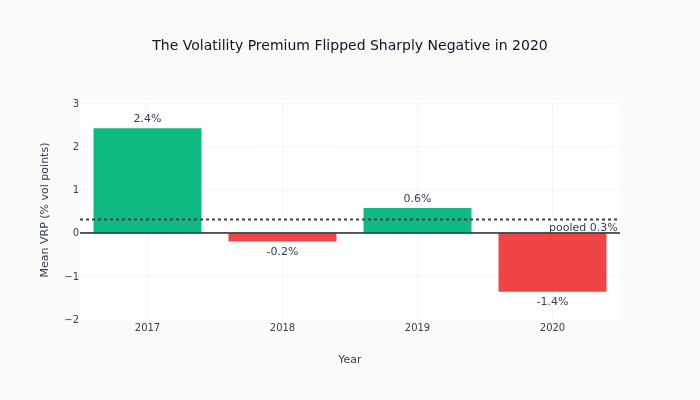

In [12]:
_years = vrp_by_year["year"].to_list()
_means = [v * 100 for v in vrp_by_year["vrp_mean"].to_list()]
fig_year = go.Figure()
fig_year.add_trace(
    go.Bar(
        x=_years,
        y=_means,
        marker_color=[COLORS["positive"] if m >= 0 else COLORS["negative"] for m in _means],
        text=[f"{m:.1f}%" for m in _means],
        textposition="outside",
        name="Mean VRP",
    )
)
fig_year.add_hline(
    y=vrp_mean * 100,
    line_dash="dot",
    line_color=COLORS["neutral"],
    annotation_text=f"pooled {vrp_mean * 100:.1f}%",
    annotation_position="bottom right",
)
fig_year.add_hline(y=0, line_color=COLORS["blue"], line_width=1)
fig_year.update_layout(
    title="The Volatility Premium Flipped Sharply Negative in 2020",
    template="ml4t",
    height=400,
    yaxis_title="Mean VRP (% vol points)",
    xaxis_title="Year",
    showlegend=False,
)
fig_year.update_xaxes(tickmode="array", tickvals=_years)
fig_year.show()

#### Paired Straddle Cost and VRP Visualisation

In [13]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Paired Straddle Round-Trip Cost", "VRP Over Time"],
)

# Costs are heavily right-skewed (a thin tail runs past 100% of mid); clip the
# display window to 0-40% so the bulk of the distribution is legible rather than
# crushed against the axis by a handful of wide-cost outliers.
_cost_xmax = 40.0
_sym_colors = ml4t_palette(len(FEASIBILITY_SYMBOLS), categorical=True)
for sym, color in zip(FEASIBILITY_SYMBOLS, _sym_colors, strict=True):
    symbol_costs = paired_straddles.filter(pl.col("symbol") == sym)[
        "round_trip_pct_of_mid"
    ].to_list()
    if symbol_costs:
        fig.add_trace(
            go.Histogram(
                x=symbol_costs,
                name=sym,
                opacity=0.6,
                marker_color=color,
                xbins=dict(start=0, end=_cost_xmax, size=1.5),
            ),
            row=1,
            col=1,
        )

The companion panel places complete-pair cost beside the daily premium. Its
40% display limit is disclosed because the extreme cost tail extends
further and would otherwise obscure the bulk of the observations.

In [14]:
vrp_ts = (
    vrp_sample.group_by("timestamp").agg(pl.col("vrp").mean().alias("vrp_mean")).sort("timestamp")
)
fig.add_trace(
    go.Scatter(
        x=vrp_ts["timestamp"].to_list(),
        y=(vrp_ts["vrp_mean"] * 100).to_list(),
        mode="lines",
        name="VRP (%)",
        line=dict(color=COLORS["positive"]),
    ),
    row=1,
    col=2,
)
_ = fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=2)

Explicit units, zero references, and the strategy sample labels make each panel
interpretable without relying on the surrounding code.

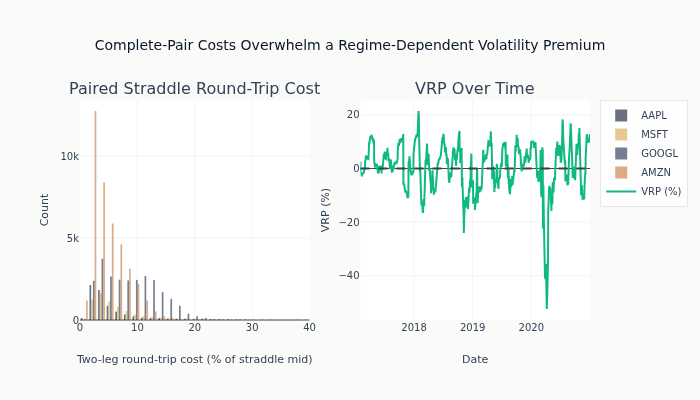

In [15]:
fig.update_layout(
    title="Complete-Pair Costs Overwhelm a Regime-Dependent Volatility Premium",
    template="ml4t",
    height=400,
    showlegend=True,
)
fig.update_xaxes(
    title_text="Two-leg round-trip cost (% of straddle mid)",
    range=[0, _cost_xmax],
    row=1,
    col=1,
)
fig.update_xaxes(title_text="Date", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="VRP (%)", row=1, col=2)

fig.show()

---

## Section C: Design Decisions

Design decisions are the strategy choices encoded in `setup.yaml` that the
feasibility evidence above supports. They are justified here, not in the YAML.

### C.1 Decision Cadence

`setup.yaml::decision.entry_cadence: weekly_friday` with `execution_delay:
monday_open` and `hedge_cadence: daily_close`. Weekly entry at the
~30-day-to-expiry sweet spot is standard for variance-risk-premium
harvesting: monthly expiries provide the deepest liquidity, weekly entries
maintain five overlapping cohorts (1/5 capital each) so the strategy is
always exposed, and daily delta hedging keeps the per-position direction
bet bounded. The 10-day variant labels (`fwd_ret_dh_10d`, `fwd_ret_10d`)
explore a shorter holding window where IV mean-reversion may be sharper.

The primary label `ret_to_expiry` follows the full ~30-day cohort with
daily-MTM P&L accounting (per `setup.yaml::labels.rebalance_step.ret_to_expiry:
5`, which is `ceil(30/7)` for the weekly schedule). Five concurrent cohorts
at 1/5 capital each are aggregated into a daily portfolio return series.

### C.2 Kill Conditions

Kill conditions are falsifiable checkpoints anchored to the feasibility
evidence above. They are documented here rather than serialised into
`setup.yaml` because the S&P 500 options pipeline does not consume
`kill_conditions` programmatically.

- **KC1 (VRP compression)**: Sample-mean VRP < 2% annualised for > 6
  months. Gate: Chapter 7 label evaluation. B.4 above measures the
  baseline VRP magnitude that motivates this threshold.
- **KC2 (cost erosion)**: Round-trip cost consumes > 50% of gross VRP edge
  even at the cascade's most aggressive rung. Gate: Chapter 18 cost
  sensitivity. B.4 measures the raw feasibility ratio that gates this
  check; the rung-3 (HTM + liquid filter) result is computed downstream.
- **KC3 (gamma loss dominance)**: Cumulative gamma losses exceed cumulative
  VRP collection over any rolling 2-year window. Gate: Chapter 19 risk
  overlay (stop-loss / max-drawdown sweep on `backtest.sweep.risk_controls`).

### C.3 Mapping Class

`setup.yaml::mapping.class: systematic_straddle_sell` with
`position_state_space: short_straddle_hedged`, `entry_logic:
sell_atm_straddle_weekly`, and `sizing: fixed_vega_notional`. The short
straddle is delta-hedged with the underlying stock at `daily_close` with a
`delta_threshold: 0.1` rehedge trigger (declared in
`setup.yaml::hedging_protocol`, consumed by `case_studies.utils.backtest_runner`).

The mapping is constrained by feasibility evidence in two ways:

- **Long-only short-vol exposure**: The straddle sign convention is encoded
  in the label construction (returns are computed for the short side), not
  via a `long_short=True` allocator setting. Top-k selection picks the
  names with the highest expected short-straddle return, executed
  long-only on the chosen straddles. This sidesteps the need for option-
  borrowing infrastructure that single-stock short-vol would otherwise
  require.

- **HTM cost cascade**: B.4 shows the raw round-trip feasibility
  ratio is well below 1.0. The strategy survives only by (a) avoiding the
  exit-leg spread entirely via hold-to-maturity (HTM), (b) sweeping all four
  entry-cost fractions `[0.203, 0.5, 0.75, 1.0]`, where 0.203 is the
  sophisticated-execution anchor, and (c) restricting to the bottom-quintile
  half-spread "liquid" subset of each rebalance date. These choices are declared
  in `setup.yaml::backtest.sweep.htm_cost_cascade` and dispatched inline
  by Chapter 18 cost notebooks; they do not flow through the standard
  `run_backtest` cost sweep.

---

## Section D: Walk-Forward Structure (Section 6.5)

We verify that the data supports the walk-forward design declared in
`setup.yaml::evaluation` (`n_splits`, `train_size`, `val_size`, `holdout_start`).

### D.1 Effective Sample Size

Five calendar years (2017-2021) of weekly-cadence data is a thin sample for
walk-forward CV. With 2-year training windows and 1-year validation windows,
only two non-overlapping folds fit before the 2021 holdout. Results will
have high variance per fold; we report this constraint rather than papering
over it.

In [16]:
sample_years = (
    pl.Series([END_DATE]).str.to_date("%Y-%m-%d").item().year
    - pl.Series([START_DATE]).str.to_date("%Y-%m-%d").item().year
    + 1
)
weekly_decisions_per_year = 52
n_decision_dates = sample_years * weekly_decisions_per_year

print("Data Coverage:")
print(f"  Period: {START_DATE} to {END_DATE}")
print(f"  Years:  {sample_years}")
print(f"  Approx weekly decision dates: {n_decision_dates}")
print(f"  Holdout: {HOLDOUT_START} to {HOLDOUT_END}")

Data Coverage:
  Period: 2017-01-01 to 2021-12-31
  Years:  5
  Approx weekly decision dates: 260
  Holdout: 2021-01-01 to 2021-12-31


### D.2 Walk-Forward Fold Demonstration

`case_studies/utils/cv_window.py` owns the operational splits; this cell
reproduces the fold boundaries from canonical `setup.yaml` parameters
(`train_size: 2Y`, `val_size: 1Y`, `n_splits: 2`) to verify the data window
supports the declared design.

In [17]:
def _generate_fold_boundaries(
    start_date: str,
    holdout_start: str,
    train_years: int,
    test_years: int,
    n_splits: int,
) -> list[dict]:
    """Generate walk-forward fold boundaries from canonical setup.yaml values."""
    folds = []
    validation_start_year = int(start_date[:4]) + train_years

    for i in range(n_splits):
        test_start_year = validation_start_year + i * test_years
        train_start_year = test_start_year - train_years
        test_end_year = test_start_year + test_years

        if f"{test_start_year}-01-01" >= holdout_start:
            break

        folds.append(
            {
                "fold": i + 1,
                "train_start": f"{train_start_year}-01-01",
                "train_end": f"{test_start_year - 1}-12-31",
                "test_start": f"{test_start_year}-01-01",
                "test_end": f"{min(test_end_year - 1, int(holdout_start[:4]) - 1)}-12-31",
            }
        )

    return folds

In [18]:
n_splits_declared = int(SETUP["evaluation"]["n_splits"])
train_years = int(str(SETUP["evaluation"]["train_size"]).rstrip("Y"))
test_years = int(str(SETUP["evaluation"]["val_size"]).rstrip("Y"))

splits = _generate_fold_boundaries(
    start_date=START_DATE,
    holdout_start=HOLDOUT_START,
    train_years=train_years,
    test_years=test_years,
    n_splits=n_splits_declared,
)

splits_df = pl.DataFrame(splits)
print(f"Generated {len(splits)} walk-forward folds")
print(splits_df)

assert len(splits) == n_splits_declared, (
    f"Expected {n_splits_declared} folds (setup.yaml), got {len(splits)}"
)
last_test_end = splits[-1]["test_end"]
assert last_test_end < HOLDOUT_START, (
    f"Last fold ({last_test_end}) overlaps holdout ({HOLDOUT_START})"
)
print(f"\nLast fold test end: {last_test_end}  |  Holdout start: {HOLDOUT_START}")

Generated 2 walk-forward folds
shape: (2, 5)
┌──────┬─────────────┬────────────┬────────────┬────────────┐
│ fold ┆ train_start ┆ train_end  ┆ test_start ┆ test_end   │
│ ---  ┆ ---         ┆ ---        ┆ ---        ┆ ---        │
│ i64  ┆ str         ┆ str        ┆ str        ┆ str        │
╞══════╪═════════════╪════════════╪════════════╪════════════╡
│ 1    ┆ 2017-01-01  ┆ 2018-12-31 ┆ 2019-01-01 ┆ 2019-12-31 │
│ 2    ┆ 2018-01-01  ┆ 2019-12-31 ┆ 2020-01-01 ┆ 2020-12-31 │
└──────┴─────────────┴────────────┴────────────┴────────────┘

Last fold test end: 2020-12-31  |  Holdout start: 2021-01-01


Two folds with annual step is the most CV depth the 4-year pre-holdout
window supports without overlapping. Downstream notebooks rely on
`case_studies.utils.cv_window.get_cv_config_v2("sp500_options")` to produce
the authoritative fold boundaries with proper purging.

---

## Section E: Derived Artifacts

The S&P 500 options strategy has no point-in-time eligibility filter at the
notebook level - universe selection (S&P 500 constituents with options
coverage) happens in `materialize_options.py`, and the cascade's liquid-rung
filter (bottom-quintile half-spread per rebalance date) is computed inline
by Chapter 18 cost notebooks. The only artifact this notebook persists is
the feasibility summary written in Section F.

---

## Section F: Findings vs `setup.yaml`

The canonical strategy declarations live in `config/setup.yaml`. This section
enumerates each declared knob alongside the feasibility evidence above that
motivates it. `setup.yaml` is not regenerated here - it is the hand-curated
source of truth, and this notebook reads it.

In [19]:
print("=" * 78)
print("Setup.yaml knobs vs feasibility evidence")
print("=" * 78)

print()
print(f"universe.underlying = {SETUP['universe']['underlying']}")
print(f"universe.strategy   = {SETUP['universe']['strategy']}")
print("  -> S&P 500 constituents with options coverage")
print(f"  -> sample symbols for spread/VRP: {FEASIBILITY_SYMBOLS}")

print()
print(f"decision.entry_cadence = {SETUP['decision']['entry_cadence']}")
print(f"decision.hedge_cadence = {SETUP['decision']['hedge_cadence']}")
print("  -> 5 weekly cohorts at 1/5 capital, ~30 DTE entry")

print()
print(f"hedging_protocol.delta_threshold = {SETUP['hedging_protocol']['delta_threshold']}")
print("  -> consumed by case_studies.utils.backtest_runner HTM cohort engine")

print()
print(f"costs.class = {SETUP['costs']['class']}")
print(f"  -> empirical mean single-leg half-spread: {half_spread_stats['mean']:.2f}%")
print(
    f"  -> complete-pair raw round-trip cost: {straddle_round_trip_cost_pct:.3f}% of straddle mid"
)
print(f"  -> pooled mean VRP (IV30 - RV21): {vrp_mean * 100:.2f}% (regime-dependent, see B.4)")
print(f"  -> raw feasibility ratio: {feasibility_ratio:.3f}x")
print("  -> raw ratio < 1.0 motivates the HTM cascade")

Setup.yaml knobs vs feasibility evidence

universe.underlying = sp500_constituents
universe.strategy   = atm_straddle
  -> S&P 500 constituents with options coverage
  -> sample symbols for spread/VRP: ['AAPL', 'MSFT', 'GOOGL', 'AMZN']

decision.entry_cadence = weekly_friday
decision.hedge_cadence = daily_close
  -> 5 weekly cohorts at 1/5 capital, ~30 DTE entry

hedging_protocol.delta_threshold = 0.1
  -> consumed by case_studies.utils.backtest_runner HTM cohort engine

costs.class = dominant
  -> empirical mean single-leg half-spread: 3.50%
  -> complete-pair raw round-trip cost: 6.713% of straddle mid
  -> pooled mean VRP (IV30 - RV21): 0.31% (regime-dependent, see B.4)
  -> raw feasibility ratio: 0.047x
  -> raw ratio < 1.0 motivates the HTM cascade


The remaining declarations connect the cost-mitigation cascade, label horizon,
and walk-forward window to their canonical configuration entries.

In [20]:
print()
print(
    f"backtest.sweep.htm_cost_cascade.cost_fractions = "
    f"{SETUP['backtest']['sweep']['htm_cost_cascade']['cost_fractions']}"
)
print(
    f"backtest.sweep.htm_cost_cascade.universes = "
    f"{SETUP['backtest']['sweep']['htm_cost_cascade']['universes']}"
)
print(
    f"backtest.sweep.htm_cost_cascade.liquid_quantile = "
    f"{SETUP['backtest']['sweep']['htm_cost_cascade']['liquid_quantile']}"
)
print(f"  -> all configured entry-cost fractions: {COST_FRACTIONS}")
print("  -> 0.203 is the execution anchor; 1.0 pays the full quoted half-spread")
print("  -> liquid universe = bottom-quintile half-spread")

print()
print(f"labels.primary = {SETUP['labels']['primary']}")
print(f"labels.variants = {SETUP['labels']['variants']}")
print("  -> primary uses 5-cohort daily-MTM accrual at ~30 DTE")
print(f"  -> rebalance_step: {SETUP['labels']['rebalance_step']}")

print()
print(f"evaluation.n_splits = {SETUP['evaluation']['n_splits']}")
print(f"evaluation.train_size = {SETUP['evaluation']['train_size']}")
print(f"evaluation.val_size   = {SETUP['evaluation']['val_size']}")
print(f"  -> generated {len(splits)} folds; declared count matches")
print(f"  -> holdout {HOLDOUT_START} to {HOLDOUT_END}; last test ends {splits[-1]['test_end']}")


backtest.sweep.htm_cost_cascade.cost_fractions = [0.203, 0.5, 0.75, 1.0]
backtest.sweep.htm_cost_cascade.universes = ['full', 'liquid']
backtest.sweep.htm_cost_cascade.liquid_quantile = 0.2
  -> all configured entry-cost fractions: [0.203, 0.5, 0.75, 1.0]
  -> 0.203 is the execution anchor; 1.0 pays the full quoted half-spread
  -> liquid universe = bottom-quintile half-spread

labels.primary = ret_to_expiry
labels.variants = []
  -> primary uses 5-cohort daily-MTM accrual at ~30 DTE
  -> rebalance_step: {'ret_to_expiry': 5}

evaluation.n_splits = 2
evaluation.train_size = 2Y
evaluation.val_size   = 1Y
  -> generated 2 folds; declared count matches
  -> holdout 2021-01-01 to 2021-12-31; last test ends 2020-12-31


### Persist Feasibility Findings

In [21]:
feasibility_report = {
    "case_study_id": CASE_STUDY_ID,
    "computed_at_utc": datetime.now(UTC).isoformat(),
    "data_period": {"start": START_DATE, "end": END_DATE},
    "sample": {
        "symbols": FEASIBILITY_SYMBOLS,
        "cv_window": {"start": FEASIBILITY_CV_START, "end": FEASIBILITY_CV_END},
        "holdout_excluded": HOLDOUT_START[:4],
        "n_atm_observations": int(atm_opts.height),
    },
    "single_leg_half_spread_pct_of_mid": {
        "mean": float(half_spread_stats["mean"]),
        "median": float(half_spread_stats["median"]),
        "q25": float(half_spread_stats["q25"]),
        "q75": float(half_spread_stats["q75"]),
        "q95": float(half_spread_stats["q95"]),
    },
    "straddle_round_trip_cost_pct_of_mid": {
        "n_pairs": int(straddle_cost_stats["n_pairs"]),
        "mean": float(straddle_cost_stats["mean"]),
        "median": float(straddle_cost_stats["median"]),
        "q25": float(straddle_cost_stats["q25"]),
        "q75": float(straddle_cost_stats["q75"]),
        "q95": float(straddle_cost_stats["q95"]),
    },
}

The VRP block preserves both the pooled estimate and each annual regime for
downstream consumers of the report.

In [22]:
feasibility_report["vrp_iv30_minus_rv21"] = {
    "mean": vrp_mean,
    "std": vrp_std,
    "positive_fraction": vrp_positive_frac,
    "note": "pooled over CV window; regime-dependent (see by_year)",
    "by_year": [
        {
            "year": int(r["year"]),
            "n_obs": int(r["n_obs"]),
            "mean": float(r["vrp_mean"]),
            "std": float(r["vrp_std"]),
            "positive_fraction": float(r["pos_frac"]),
        }
        for r in vrp_by_year.iter_rows(named=True)
    ],
}

The final blocks record the economic assessment and the demonstrated
walk-forward capacity before the report is written to the isolated output path.

In [23]:
feasibility_report["feasibility"] = {
    "round_trip_cost_pct_of_straddle_mid": float(straddle_round_trip_cost_pct),
    "ratio_vrp_over_round_trip_cost": float(feasibility_ratio),
    "assessment": (
        "not_viable"
        if feasibility_ratio < 1.0
        else "marginal"
        if feasibility_ratio < 2.0
        else "viable"
    ),
    "motivates": "htm_cost_cascade (setup.yaml::backtest.sweep.htm_cost_cascade)",
}
feasibility_report["walk_forward"] = {
    "n_folds_generated": int(len(splits)),
    "n_splits_declared": n_splits_declared,
    "train_years": train_years,
    "test_years": test_years,
    "holdout_start": HOLDOUT_START,
    "holdout_end": HOLDOUT_END,
    "last_test_end": splits[-1]["test_end"],
}

Writing the compact JSON report lets downstream notebooks cite the feasibility
evidence without loading the raw option chain.

In [24]:
report_path = EXPLORATION_DIR / "feasibility_report.json"
with open(report_path, "w") as f:
    json.dump(feasibility_report, f, indent=2)
print(f"Written: {report_path}")

Written: /tmp/ml4t-sp500-options-01-current-20260721/sp500_options/config/exploration/feasibility_report.json


---

## Key Takeaways

1. **Costs dominate at quoted spreads**: The mean single-leg half-spread is
   multiple percent of option mid. Across complete call-put pairs, the raw
   entry-plus-exit cost is larger than the premium in every year of the window,
   and the feasibility ratio is below 1.0.
2. **The premium is regime-dependent, not a fixed edge**: Mean IV30 - RV21 is
   thin but positive over the pooled CV window and turns negative in the 2020
   volatility spike. Selling volatility is not a standing edge merely taxed
   by costs; the raw premium itself can go negative before any cost is paid.
3. **Strategy survives only via the HTM cascade**: `setup.yaml::backtest.sweep.htm_cost_cascade`
   combines HTM with four configured entry-cost fractions and two universes
   (HTM avoids the exit leg; `[0.203, 0.5, 0.75, 1.0]` spans the cost grid;
   the liquid filter restricts to the bottom-quintile half-spread universe).
   Chapter 18 cost notebooks
   dispatch these inline.
4. **Limited walk-forward depth**: 5 calendar years supports only 2 folds
   with 2Y train + 1Y validation before the 2021 holdout. Variance per
   fold will be high; the holdout is the credible single-point estimate.
5. **No point-in-time eligibility artifact**: Universe selection happens
   upstream (`materialize_options.py`); the liquid-rung filter is computed
   inline at backtest time.

**Artifacts written**:

- `config/exploration/feasibility_report.json`: spread distribution,
  VRP magnitude, feasibility ratio, and walk-forward summary that downstream
  notebooks and the chapter README can cite without re-running this notebook.

**Next**: [`02_labels`](02_labels.ipynb) computes forward short-straddle
returns (primary `ret_to_expiry`, variants `fwd_ret_dh_*` and `fwd_ret_*`)
with the declared rebalance steps.